# Thai HCR v2 — 2-phase curriculum (D1 ตัวพิมพ์ → D2+D3 ลายมือ)

ไฟล์นี้ **รันได้อิสระ** ไม่ต้องเปิด `test_phet.ipynb` ประกอบ โค้ด preprocessing/class mapping คัดลอกมาไว้ครบในไฟล์นี้

| | |
|---|---|
| Phase 1 | D1 (ตัวพิมพ์) 4 epoch · CrossEntropy + Label Smoothing 0.1 |
| Phase 2 | D2+D3 (ลายมือ) 11 epoch · Class-Balanced Focal Loss + Square-Root Sampling |
| Validation | stratified 20% จาก **ทั้ง 3 source** — เลือก best checkpoint จากชุดนี้ (กันโมเดลลืมตัวพิมพ์) |
| Augment | RandomAffine → ElasticTransform → RandomErasing (ทั้ง 2 phase, parameter คงที่ทุก epoch) |

**ของเดิมห้ามแตะ**: output ทุกไฟล์ลง `outputs_v2/` และ checkpoint คือ `checkpoints/best_resnet50_v2.pt` เท่านั้น

In [1]:
# 1. Imports + config (v2 เขียนแยกจากของเดิมทั้งหมด)
import os, csv, time, random, unicodedata
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image
from skimage.filters import threshold_sauvola
from skimage.measure import label as cc_label
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms.v2 as T
from torchvision.models import resnet50, ResNet50_Weights

PROJECT_ROOT = Path.cwd()
DATA_ROOT    = PROJECT_ROOT / "data"
OUT_DIR      = PROJECT_ROOT / "outputs_v2"                            # ห้ามเขียนลง outputs/ เดิม
CKPT_DIR     = PROJECT_ROOT / "checkpoints"
CKPT_PATH    = CKPT_DIR / "best_resnet50_v2.pt"                       # ห้ามทับ best_resnet50.pt เดิม
PHASE1_PATH  = CKPT_DIR / "phase1_resnet50_v2.pt"
OUT_DIR.mkdir(exist_ok=True); CKPT_DIR.mkdir(exist_ok=True)

def v2_path(p: Path) -> Path:
    """กันเขียนทับไฟล์ของรอบเดิม: อนุญาตเฉพาะใต้ outputs_v2/ หรือชื่อไฟล์ลงท้าย _v2"""
    p = Path(p)
    ok = OUT_DIR in p.parents or p.stem.endswith("_v2")
    if not ok: raise RuntimeError(f"ปฏิเสธการเขียน {p} — ไม่ได้อยู่ใต้ outputs_v2/ และชื่อไม่ลงท้าย _v2")
    return p

SEED            = 42
VAL_SIZE        = 0.20
PHASE1_EPOCHS   = 4          # D1 ตัวพิมพ์
PHASE2_EPOCHS   = 11         # D2+D3 ลายมือ  (รวม 15 epoch เท่ารอบเดิม)
BATCH_SIZE      = 128
LR              = 5e-4
WEIGHT_DECAY    = 1e-2
LABEL_SMOOTHING = 0.1
CB_BETA         = 0.9999     # Class-Balanced Loss (Cui et al. 2019)
FOCAL_GAMMA     = 2.0
TARGET          = 64         # ขนาดภาพหลัง preprocess
MARGIN          = 4
INPUT_SIZE      = 128        # ขยายในโมเดล (ResNet-50 ย่อ 32 เท่า)
NUM_WORKERS     = 6
USE_CACHE       = True
USE_AMP         = True
SMOKE_TEST      = False      # True = ข้อมูล 2%, phase ละ 1 epoch (ใช้เช็คว่าโค้ดรันจบ) · False = รันเต็ม 4+11 epoch
GRAY_MEAN, GRAY_STD = 0.449, 0.226

SOURCE_NAME = {"D1": "Teacher (ตัวพิมพ์)", "D2": "Burapha-TH (ลายมือ)", "D3": "THI-C168 (ลายมือ)"}
IMG_EXTS    = {".jpg", ".jpeg", ".png"}
IGNORE      = {".DS_Store"}
PHASE1_SRC  = ("D1",)
PHASE2_SRC  = ("D2", "D3")
# ภาพว่างเปล่า (ไม่มีตัวอักษร) ที่เจอจากการสแกนทั้ง dataset — ตัดออกทั้ง train/val
BLANK_NAMES = {"Set5_F1_P-0166_1.jpg", "Set5_F1_P-0166_123.jpg", "Set5_F1_P-0166_133.jpg"}

device = "mps" if torch.backends.mps.is_available() else "cpu"
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
for f in ["/System/Library/Fonts/Supplemental/Ayuthaya.ttf", "/System/Library/Fonts/Thonburi.ttc"]:
    if Path(f).exists():
        font_manager.fontManager.addfont(f); plt.rcParams["font.family"] = font_manager.FontProperties(fname=f).get_name(); break
print(f"device = {device} | SMOKE_TEST = {SMOKE_TEST} | out -> {OUT_DIR.name}/ | ckpt -> {CKPT_PATH.name}")

device = mps | SMOKE_TEST = False | out -> outputs_v2/ | ckpt -> best_resnet50_v2.pt


In [2]:
# 2. Class mapping (TIS-620) + index ของไฟล์จริง — สแกน data/ ใหม่ในไฟล์นี้เอง
def tis620_char(code: int) -> str:
    """รหัสโฟลเดอร์ (TIS-620 byte) -> ตัวอักษรไทย เช่น 161 -> 'ก'"""
    return bytes([int(code)]).decode("tis-620")

def build_index(data_root=DATA_ROOT, tops=("character", "number")):
    """คืน list ของ (path, code, source) จากโครงสร้างจริง <top>/<code>/<D1|D2|D3>/<file>"""
    items = []
    for top in tops:
        for cls_dir in sorted((data_root / top).iterdir(), key=lambda d: d.name):
            if not (cls_dir.is_dir() and cls_dir.name.isdigit()): continue
            for src_dir in sorted(cls_dir.iterdir()):
                if not (src_dir.is_dir() and src_dir.name in SOURCE_NAME): continue
                for f in sorted(src_dir.iterdir()):
                    if f.suffix.lower() in IMG_EXTS and f.name not in IGNORE and f.name not in BLANK_NAMES:
                        items.append((f, int(cls_dir.name), src_dir.name))
    return items

index       = build_index()
CLASS_CODES = sorted({code for _, code, _ in index})
CODE_TO_IDX = {c: i for i, c in enumerate(CLASS_CODES)}
IDX_TO_CHAR = [tis620_char(c) for c in CLASS_CODES]
NUM_CLASSES = len(CLASS_CODES)
samples     = [(p, CODE_TO_IDX[c], s) for p, c, s in index]

assert tis620_char(161) == "ก" and tis620_char(206) == "ฮ" and tis620_char(240) == "๐" and tis620_char(249) == "๙"
src_cnt = defaultdict(int)
for _, _, s in samples: src_cnt[s] += 1
print(f"ภาพ {len(samples):,} | NUM_CLASSES = {NUM_CLASSES} | " + " · ".join(f"{s} {src_cnt[s]:,}" for s in sorted(src_cnt)))

def disp(ch):
    """สระบน/ล่าง/วรรณยุกต์ (combining mark) -> เกาะกับ อ ให้แสดงผลในกราฟได้"""
    return "อ" + ch if unicodedata.category(ch) == "Mn" else ch

ภาพ 163,278 | NUM_CLASSES = 81 | D1 62,519 · D2 76,924 · D3 23,835


In [3]:
# 3. Preprocessing pipeline (คัดลอกมาครบ: polarity -> Sauvola -> crop -> resize -> letterbox)
def load_gray(path) -> np.ndarray:
    with Image.open(path) as im:
        return np.asarray(im.convert("L"), dtype=np.uint8)

def border_dark_fraction(g: np.ndarray) -> float:
    return float((np.concatenate([g[0], g[-1], g[:, 0], g[:, -1]]) < 128).mean())

def normalize_polarity(g: np.ndarray) -> np.ndarray:
    """ทำให้เป็น 'หมึกเข้ม พื้นสว่าง' — D1 crop ชิด+เส้นหนา ทำให้ขอบมืดได้ถึง 94% ทั้งที่ไม่ได้กลับสี
    จึงกลับสีเฉพาะเมื่อขอบมืด >= 97% (ทั้ง dataset ไม่มีภาพกลับสีจริง เก็บไว้เผื่อ test set)"""
    if int(g.max()) - int(g.min()) < 30: return g
    return 255 - g if border_dark_fraction(g) >= 0.97 else g

def sauvola_binarize(g: np.ndarray, k: float = 0.2) -> np.ndarray:
    if int(g.max()) - int(g.min()) < 30:                  # ภาพสีเดียว เช่น '่' ใน D1 ที่เป็นหมึกทั้งภาพ
        return np.full(g.shape, g.mean() < 128)
    h, w = g.shape
    win = max(3, min(25, (min(h, w) // 2) | 1))
    t = threshold_sauvola(g, window_size=win, k=k)
    bg = float(np.percentile(g, 99))
    ink = ((g < t) | (g < 0.5 * bg)) & (g < bg - 30)      # guard: กันกรอบจางใน D2 / กัน Sauvola เจาะรูกลางเส้นหนา
    lab = cc_label(ink, connectivity=2)
    if lab.max() > 1:
        areas = np.bincount(lab.ravel()); areas[0] = 0
        ink = np.isin(lab, np.flatnonzero(areas >= 0.01 * areas.sum()))
    return ink

def tight_crop(mask: np.ndarray) -> np.ndarray:
    ys, xs = np.nonzero(mask)
    if len(ys) == 0: return mask
    return mask[ys.min():ys.max() + 1, xs.min():xs.max() + 1]

def resize_keep_aspect(mask: np.ndarray, box: int = TARGET - 2 * MARGIN) -> np.ndarray:
    h, w = mask.shape
    s = box / max(h, w)
    nh, nw = max(1, round(h * s)), max(1, round(w * s))
    interp = cv2.INTER_AREA if s < 1 else cv2.INTER_LINEAR
    return cv2.resize(mask.astype(np.uint8) * 255, (nw, nh), interpolation=interp)

def letterbox_centroid(glyph: np.ndarray, size: int = TARGET) -> np.ndarray:
    h, w = glyph.shape
    m = cv2.moments(glyph, binaryImage=False)
    cy, cx = (m["m01"] / m["m00"], m["m10"] / m["m00"]) if m["m00"] > 0 else (h / 2, w / 2)
    top  = int(np.clip(round(size / 2 - cy), 0, size - h))
    left = int(np.clip(round(size / 2 - cx), 0, size - w))
    canvas = np.zeros((size, size), np.uint8)
    canvas[top:top + h, left:left + w] = glyph
    return canvas

def preprocess(path) -> np.ndarray:
    """path -> uint8 (TARGET×TARGET) หมึก=255 พื้น=0"""
    return letterbox_centroid(resize_keep_aspect(tight_crop(sauvola_binarize(normalize_polarity(load_gray(path))))))

_p, _y, _s = samples[0]
print(f"ตรวจ preprocess: {_p.relative_to(DATA_ROOT)} -> shape {preprocess(_p).shape} dtype {preprocess(_p).dtype} "
      f"max {preprocess(_p).max()} | label {_y} '{IDX_TO_CHAR[_y]}' | source {_s}")

ตรวจ preprocess: character/161/D1/bc_001sg_3_118.jpg -> shape (64, 64) dtype uint8 max 255 | label 0 'ก' | source D1


In [4]:
# 4. Stratified split 80/20 จากทั้ง 3 source + แยก index ของแต่ละ phase
all_y   = np.array([y for _, y, _ in samples])
all_src = np.array([s for _, _, s in samples])
train_idx, val_idx = train_test_split(np.arange(len(samples)), test_size=VAL_SIZE, stratify=all_y, random_state=SEED)

if SMOKE_TEST:                                   # ข้อมูล 2% ต่อ phase (ยังคงสัดส่วนคลาสเดิมโดยประมาณ)
    train_idx, val_idx = train_idx[::50], val_idx[::50]

p1_train = train_idx[np.isin(all_src[train_idx], PHASE1_SRC)]     # D1 เท่านั้น
p2_train = train_idx[np.isin(all_src[train_idx], PHASE2_SRC)]     # D2 + D3
va_cnt   = np.bincount(all_y[val_idx], minlength=NUM_CLASSES)

print(f"train {len(train_idx):,} (phase1 D1 {len(p1_train):,} · phase2 D2+D3 {len(p2_train):,}) | val {len(val_idx):,}")
for name, idx in [("phase1", p1_train), ("phase2", p2_train)]:
    n_cls = len(set(all_y[idx]))
    missing = [IDX_TO_CHAR[c] for c in range(NUM_CLASSES) if c not in set(all_y[idx])]
    print(f"  {name}: {n_cls}/{NUM_CLASSES} คลาส" + (f" · ไม่มีในเฟสนี้: {missing}" if missing and len(missing) <= 15 else ""))
print(f"val: {int((va_cnt > 0).sum())}/{NUM_CLASSES} คลาส | ต่อคลาส min {va_cnt.min()} max {va_cnt.max()} | "
      + " · ".join(f"{s} {int((all_src[val_idx] == s).sum()):,}" for s in ["D1", "D2", "D3"]))

train 130,622 (phase1 D1 50,035 · phase2 D2+D3 80,587) | val 32,656
  phase1: 75/81 คลาส · ไม่มีในเฟสนี้: ['ฃ', 'ฆ', 'ฌ', 'ฦ', 'ำ', '๋']
  phase2: 80/81 คลาส · ไม่มีในเฟสนี้: ['ๅ']
val: 81/81 คลาส | ต่อคลาส min 34 max 1238 | D1 12,484 · D2 15,443 · D3 4,729


In [5]:
# 5. Dataset + augmentation (ชุดเดียวกับรอบเดิมทุกตัว พารามิเตอร์คงที่ทุก epoch)
if USE_CACHE:                                     # cache ผล preprocess() ไว้ใน RAM แชร์ข้าม worker (~0.7 GB เมื่อรันเต็ม)
    CACHE  = torch.zeros((len(samples), TARGET, TARGET), dtype=torch.uint8).share_memory_()
    CACHED = torch.zeros(len(samples), dtype=torch.bool).share_memory_()

train_tf = T.Compose([
    T.RandomAffine(degrees=10, translate=(0.08, 0.08), scale=(0.85, 1.10), shear=8,
                   interpolation=T.InterpolationMode.BILINEAR, fill=0),
    T.RandomApply([T.ElasticTransform(alpha=30.0, sigma=5.0, fill=0)], p=0.3),
    T.ToDtype(torch.float32, scale=True),
    T.RandomErasing(p=0.25, scale=(0.02, 0.08), ratio=(0.3, 3.3), value=0.0),
    T.Normalize([GRAY_MEAN], [GRAY_STD]),
])
val_tf = T.Compose([T.ToDtype(torch.float32, scale=True), T.Normalize([GRAY_MEAN], [GRAY_STD])])

class ThaiCharDataset(Dataset):
    """preprocess() ทำตอน __getitem__ (ไม่ทำล่วงหน้าเป็นไฟล์) แล้วค่อย augment — ภาพจึงสุ่มใหม่ทุก epoch"""
    def __init__(self, indices, transform):
        self.indices, self.transform = np.asarray(indices), transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        j = int(self.indices[i])
        path, label, _ = samples[j]
        if USE_CACHE and CACHED[j]:
            img = CACHE[j]
        else:
            img = torch.from_numpy(preprocess(path))
            if USE_CACHE: CACHE[j] = img; CACHED[j] = True
        return self.transform(img.unsqueeze(0)), label

def _worker_init(_):
    cv2.setNumThreads(0); torch.set_num_threads(1)

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, worker_init_fn=_worker_init)
if NUM_WORKERS > 0:      # notebook บน macOS: spawn หาคลาสที่ประกาศในสมุดไม่เจอ -> ใช้ fork
    loader_kw.update(multiprocessing_context="fork", persistent_workers=True, prefetch_factor=4)

# Phase 2 ใช้ Square-Root Sampling: โอกาสถูกสุ่มของคลาส c เป็นสัดส่วนกับ sqrt(n_c) -> น้ำหนักต่อภาพ = 1/sqrt(n_c)
p2_counts  = np.bincount(all_y[p2_train], minlength=NUM_CLASSES)
p2_weights = 1.0 / np.sqrt(np.maximum(p2_counts[all_y[p2_train]], 1))
p2_sampler = WeightedRandomSampler(torch.tensor(p2_weights, dtype=torch.double), num_samples=len(p2_train), replacement=True)

p1_loader  = DataLoader(ThaiCharDataset(p1_train, train_tf), shuffle=True, drop_last=True, **loader_kw)
p2_loader  = DataLoader(ThaiCharDataset(p2_train, train_tf), sampler=p2_sampler, drop_last=True, **loader_kw)
val_loader = DataLoader(ThaiCharDataset(val_idx, val_tf), shuffle=False, **loader_kw)
print(f"batches — phase1 {len(p1_loader)} | phase2 {len(p2_loader)} | val {len(val_loader)}")

batches — phase1 390 | phase2 629 | val 256


In [6]:
# 6. Model: ResNet-50 (ImageNet) -> conv1 1-channel (รวม weight RGB = เท่ากับ repeat ภาพ 3 ช่อง), FC -> 81
class ThaiHCRNet(nn.Module):
    def __init__(self, num_classes, input_size=INPUT_SIZE, pretrained=True):
        super().__init__()
        net = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2 if pretrained else None)
        old = net.conv1
        net.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        with torch.no_grad():
            net.conv1.weight.copy_(old.weight.sum(dim=1, keepdim=True))
        net.fc = nn.Linear(net.fc.in_features, num_classes)
        self.net, self.input_size = net, input_size
    def forward(self, x):
        if x.shape[-1] != self.input_size:
            x = F.interpolate(x, size=(self.input_size, self.input_size), mode="bilinear", align_corners=False)
        return self.net(x)

class CBFocalLoss(nn.Module):
    """Class-Balanced Focal Loss (Cui et al. 2019): น้ำหนักคลาส = (1-beta)/(1-beta^n_c) + focal term (1-pt)^gamma"""
    def __init__(self, counts, beta=CB_BETA, gamma=FOCAL_GAMMA):
        super().__init__()
        n = np.maximum(np.asarray(counts, dtype=np.float64), 1.0)
        w = (1.0 - beta) / (1.0 - np.power(beta, n))
        w = w / w.sum() * len(n)                       # ปรับให้ค่าเฉลี่ยน้ำหนัก = 1
        self.register_buffer("w", torch.tensor(w, dtype=torch.float32))
        self.gamma = gamma
    def forward(self, logits, target):
        logp  = F.log_softmax(logits, dim=1)
        logpt = logp.gather(1, target[:, None]).squeeze(1)
        return (-self.w[target] * (1.0 - logpt.exp()).pow(self.gamma) * logpt).mean()

model = ThaiHCRNet(NUM_CLASSES).to(device)
ce_loss = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)          # phase 1
cb_loss = CBFocalLoss(p2_counts).to(device)                             # phase 2
print(f"params {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M | conv1 {tuple(model.net.conv1.weight.shape)} | "
      f"fc {tuple(model.net.fc.weight.shape)} | CB weight min {cb_loss.w.min():.3f} max {cb_loss.w.max():.3f}")

params 23.7M | conv1 (64, 1, 7, 7) | fc (81, 2048) | CB weight min 0.069 max 74.041


In [7]:
# 7. Train / eval helpers
def run_epoch(loader, criterion, optimizer=None, collect_src=False):
    train = optimizer is not None
    model.train(train)
    total_loss, y_true, y_pred = 0.0, [], []
    with torch.set_grad_enabled(train):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            with torch.autocast(device_type=device, dtype=torch.bfloat16, enabled=USE_AMP):
                logits = model(x)
                loss = criterion(logits.float(), y)
            if train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(y)
            y_true.append(y.cpu()); y_pred.append(logits.argmax(1).cpu())
    y_true, y_pred = torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()
    out = {"loss": total_loss / len(y_true), "acc": float((y_true == y_pred).mean()),
           "f1": f1_score(y_true, y_pred, average="macro", labels=range(NUM_CLASSES), zero_division=0)}
    return (out, y_true, y_pred) if collect_src else out

history, best_f1 = [], -1.0

def log_epoch(phase, epoch, lr_now, tr, va, t0):
    """เขียน history ทับทุก epoch (กัน log หายถ้าหลุดกลางคืน) + เซฟ checkpoint เมื่อ val macro F1 ดีที่สุด"""
    global best_f1
    row = {"phase": phase, "epoch": epoch, "lr": lr_now,
           **{f"train_{k}": v for k, v in tr.items()}, **{f"val_{k}": v for k, v in va.items()},
           "seconds": round(time.perf_counter() - t0, 1)}
    history.append(row)
    improved = va["f1"] > best_f1
    if improved:
        best_f1 = va["f1"]
        torch.save({"model_state": model.state_dict(), "phase": phase, "epoch": epoch,
                    "val_f1": va["f1"], "val_acc": va["acc"], "num_classes": NUM_CLASSES,
                    "class_codes": CLASS_CODES, "idx_to_char": IDX_TO_CHAR, "input_size": INPUT_SIZE,
                    "target": TARGET, "gray_mean": GRAY_MEAN, "gray_std": GRAY_STD}, v2_path(CKPT_PATH))
    with open(v2_path(OUT_DIR / "train_history.csv"), "w", newline="") as fh:
        w = csv.DictWriter(fh, fieldnames=list(row)); w.writeheader(); w.writerows(history)
    print(f"[P{phase} {epoch:>2}] {row['seconds']:5.0f}s lr {lr_now:.1e} | "
          f"train loss {tr['loss']:.3f} acc {tr['acc']:.4f} F1 {tr['f1']:.4f} | "
          f"val loss {va['loss']:.3f} acc {va['acc']:.4f} F1 {va['f1']:.4f}" + ("  * saved best" if improved else ""))

In [8]:
# 8. Phase 1 — pretrain บน D1 (ตัวพิมพ์) ด้วย CE + Label Smoothing
epochs1 = 1 if SMOKE_TEST else PHASE1_EPOCHS
opt1    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched1  = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=epochs1)

for epoch in range(1, epochs1 + 1):
    t0 = time.perf_counter()
    tr = run_epoch(p1_loader, ce_loss, opt1)
    va = run_epoch(val_loader, ce_loss)                 # val = ทั้ง 3 source เสมอ
    lr_now = opt1.param_groups[0]["lr"]; sched1.step()
    log_epoch(1, epoch, lr_now, tr, va, t0)

torch.save({"model_state": model.state_dict(), "epochs": epochs1}, v2_path(PHASE1_PATH))
print(f"phase 1 จบ -> {PHASE1_PATH.name}")

[P1  1]   513s lr 5.0e-04 | train loss 0.963 acc 0.9426 F1 0.6996 | val loss 2.082 acc 0.6346 F1 0.4619  * saved best
[P1  2]   546s lr 4.3e-04 | train loss 0.813 acc 0.9833 F1 0.8104 | val loss 1.934 acc 0.6747 F1 0.5129  * saved best
[P1  3]   556s lr 2.5e-04 | train loss 0.794 acc 0.9873 F1 0.8447 | val loss 1.905 acc 0.6837 F1 0.5269  * saved best
[P1  4]   626s lr 7.3e-05 | train loss 0.786 acc 0.9894 F1 0.8549 | val loss 1.864 acc 0.6967 F1 0.5456  * saved best
phase 1 จบ -> phase1_resnet50_v2.pt


In [9]:
# 9. Phase 2 — โหลด weight จาก phase 1 มาต่อ, เทรนบน D2+D3 (ลายมือ) ด้วย CB Focal + Square-Root Sampling
model.load_state_dict(torch.load(PHASE1_PATH, map_location=device)["model_state"])   # เริ่มจาก weight ของ phase 1 ชัดเจน
epochs2 = 1 if SMOKE_TEST else PHASE2_EPOCHS
opt2    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)    # optimizer/scheduler ชุดใหม่
sched2  = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=epochs2)

for epoch in range(1, epochs2 + 1):
    t0 = time.perf_counter()
    tr = run_epoch(p2_loader, cb_loss, opt2)
    va = run_epoch(val_loader, ce_loss)                 # วัด val ด้วย CE เสมอ เพื่อเทียบข้าม phase ได้
    lr_now = opt2.param_groups[0]["lr"]; sched2.step()
    log_epoch(2, epoch, lr_now, tr, va, t0)

best = max(history, key=lambda r: r["val_f1"])
print(f"\nbest: phase {best['phase']} epoch {best['epoch']} | val macro F1 {best['val_f1']:.4f} acc {best['val_acc']:.4f} -> {CKPT_PATH.name}")

[P2  1]   918s lr 5.0e-04 | train loss 0.015 acc 0.8879 F1 0.8759 | val loss 1.397 acc 0.9070 F1 0.8890  * saved best
[P2  2]   861s lr 4.9e-04 | train loss 0.008 acc 0.9269 F1 0.9147 | val loss 1.461 acc 0.9111 F1 0.9032  * saved best
[P2  3]   848s lr 4.6e-04 | train loss 0.007 acc 0.9368 F1 0.9240 | val loss 1.513 acc 0.9126 F1 0.8990
[P2  4]   852s lr 4.1e-04 | train loss 0.005 acc 0.9450 F1 0.9328 | val loss 1.517 acc 0.9259 F1 0.9182  * saved best
[P2  5]   839s lr 3.5e-04 | train loss 0.005 acc 0.9492 F1 0.9371 | val loss 1.556 acc 0.9089 F1 0.9017
[P2  6]   849s lr 2.9e-04 | train loss 0.004 acc 0.9567 F1 0.9444 | val loss 1.560 acc 0.9250 F1 0.9186  * saved best
[P2  7]   839s lr 2.1e-04 | train loss 0.003 acc 0.9634 F1 0.9513 | val loss 1.593 acc 0.9310 F1 0.9207  * saved best
[P2  8]   822s lr 1.5e-04 | train loss 0.003 acc 0.9682 F1 0.9561 | val loss 1.644 acc 0.9355 F1 0.9274  * saved best
[P2  9]   845s lr 8.6e-05 | train loss 0.002 acc 0.9736 F1 0.9612 | val loss 1.645 a

In [10]:
# 10. ประเมิน best checkpoint แยกตาม source (D1 / D2 / D3) — ทำครั้งเดียวตอนจบ
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"]); model.eval()

val_src = all_src[val_idx]
_, y_true, y_pred = run_epoch(val_loader, ce_loss, collect_src=True)      # val_loader ไม่ shuffle ลำดับตรงกับ val_idx

rows = []
for name, mask in [("ALL", np.ones(len(val_src), bool)), *[(s, val_src == s) for s in ["D1", "D2", "D3"]]]:
    yt, yp = y_true[mask], y_pred[mask]
    present = sorted(set(yt.tolist()))                                    # macro F1 เฉพาะคลาสที่มีจริงใน source นั้น
    rows.append({"source": name, "desc": SOURCE_NAME.get(name, "ทั้งหมด"), "n_images": int(mask.sum()),
                 "n_classes": len(present), "accuracy": round(float((yt == yp).mean()), 4),
                 "macro_f1": round(f1_score(yt, yp, average="macro", labels=present, zero_division=0), 4)})

with open(v2_path(OUT_DIR / "eval_by_source.csv"), "w", newline="", encoding="utf-8-sig") as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0])); w.writeheader(); w.writerows(rows)

print(f"best checkpoint: phase {ckpt['phase']} epoch {ckpt['epoch']}\n")
print(f"{'source':<7}{'คำอธิบาย':<24}{'ภาพ':>8}{'คลาส':>7}{'accuracy':>11}{'macro F1':>11}")
for r in rows:
    print(f"{r['source']:<7}{r['desc']:<24}{r['n_images']:>8,}{r['n_classes']:>7}{r['accuracy']:>11.4f}{r['macro_f1']:>11.4f}")

best checkpoint: phase 2 epoch 11

source คำอธิบาย                     ภาพ   คลาส   accuracy   macro F1
ALL    ทั้งหมด                   32,656     81     0.9375     0.9311
D1     Teacher (ตัวพิมพ์)        12,484     72     0.9062     0.7786
D2     Burapha-TH (ลายมือ)       15,443     68     0.9529     0.9554
D3     THI-C168 (ลายมือ)          4,729     77     0.9700     0.9724


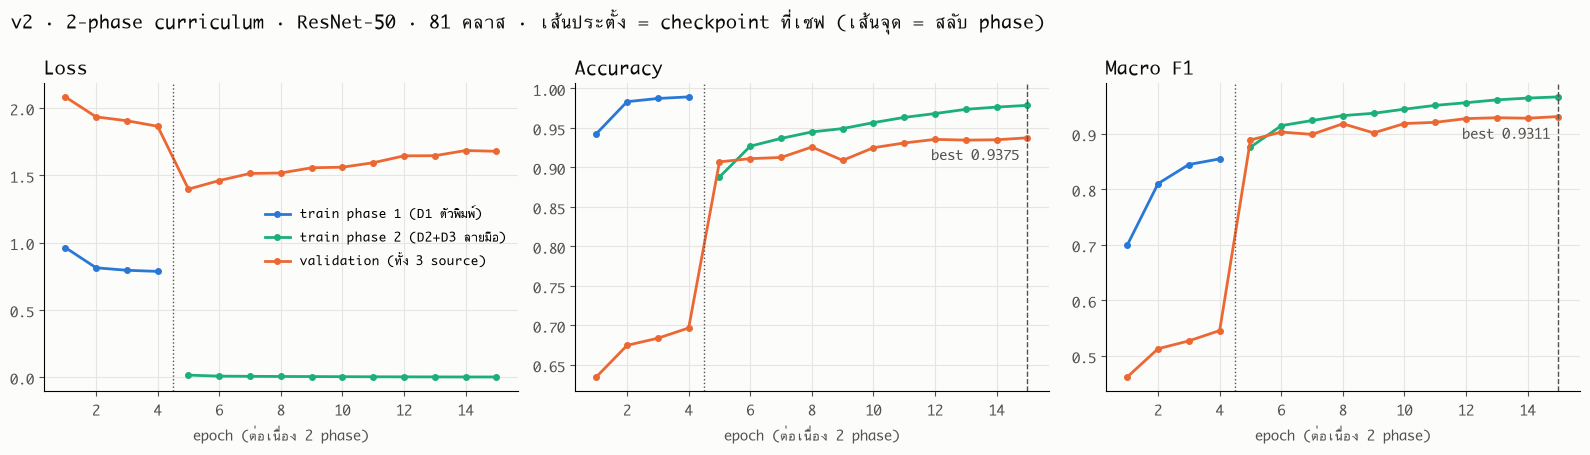

ไฟล์ที่เขียนรอบนี้: ['eval_by_source.csv', 'train_history.csv', 'training_curves_v2.png'] + best_resnet50_v2.pt phase1_resnet50_v2.pt


In [11]:
# 11. กราฟ training (สำหรับ presentation) -> outputs_v2/training_curves_v2.png
P1_C, P2_C, VAL_C = "#2a78d6", "#1baf7a", "#eb6834"
INK, INK2, GRID, SURF = "#0b0b0b", "#52514e", "#e6e5e1", "#fcfcfb"
step = np.arange(1, len(history) + 1)
n1   = sum(r["phase"] == 1 for r in history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), facecolor=SURF)
for ax, key, name in zip(axes, ["loss", "acc", "f1"], ["Loss", "Accuracy", "Macro F1"]):
    ax.set_facecolor(SURF)
    tr_v = [r[f"train_{key}"] for r in history]
    ax.plot(step[:n1], tr_v[:n1], color=P1_C, lw=2, marker="o", ms=4, label="train phase 1 (D1 ตัวพิมพ์)")
    ax.plot(step[n1:], tr_v[n1:], color=P2_C, lw=2, marker="o", ms=4, label="train phase 2 (D2+D3 ลายมือ)")
    ax.plot(step, [r[f"val_{key}"] for r in history], color=VAL_C, lw=2, marker="o", ms=4, label="validation (ทั้ง 3 source)")
    if n1: ax.axvline(n1 + 0.5, color=INK2, lw=1, ls=":")
    if key != "loss":
        bi = int(np.argmax([r["val_f1"] for r in history]))
        ax.axvline(step[bi], color=INK2, lw=1, ls="--")
        ax.annotate(f"best {history[bi][f'val_{key}']:.4f}", (step[bi], history[bi][f"val_{key}"]),
                    textcoords="offset points", xytext=(-6, -16), ha="right", color=INK2, fontsize=10)
    ax.set_title(name, loc="left", fontsize=13, color=INK); ax.set_xlabel("epoch (ต่อเนื่อง 2 phase)", color=INK2)
    ax.tick_params(colors=INK2); ax.grid(True, color=GRID, lw=0.8); ax.set_axisbelow(True)
    for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle(f"v2 · 2-phase curriculum · ResNet-50 · {NUM_CLASSES} คลาส · เส้นประตั้ง = checkpoint ที่เซฟ (เส้นจุด = สลับ phase)",
             x=0.01, ha="left", fontsize=13, color=INK)
plt.tight_layout(); plt.savefig(v2_path(OUT_DIR / "training_curves_v2.png"), dpi=150, facecolor=SURF); plt.show()
print("ไฟล์ที่เขียนรอบนี้:", sorted(p.name for p in OUT_DIR.iterdir()), "+", CKPT_PATH.name, PHASE1_PATH.name)